# GMF Investments — Time Series Forecasting for Portfolio Management
## Task 2 (Initial Progress): Chronological Train/Test Split & Initial ARIMA Model

**Analyst:** _[Your Name]_
**Date:** _[Fill in submission date]_

This notebook covers the **initial Task 2 progress** deliverable: a chronologically
correct train/test split for TSLA, and a first fitted forecasting model (ARIMA via
`pmdarima.auto_arima`) with forecasts generated over the held-out test period.

**Dependency:** This notebook assumes Task 1 (`01_task1_eda.ipynb`) has already been
run at least once, so that `data/processed/TSLA.csv` (raw fetched data) exists. If that
file is not present, the fetch cell below will pull it directly from Yahoo Finance instead.


## 0. Setup

In [1]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data_loader import fetch_ticker_data, DataFetchError
from src.preprocessing import enforce_numeric_types, handle_missing_values, calculate_daily_returns
from src.modeling import (
    chronological_train_test_split,
    fit_auto_arima,
    forecast_arima,
    evaluate_forecast,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


## 1. Load TSLA Data

Loads the cleaned TSLA price series either from the CSV saved during Task 1
(`data/processed/TSLA.csv`) or, if unavailable, fetches it directly.


In [2]:
csv_path = "../data/processed/TSLA.csv"

if os.path.exists(csv_path):
    tsla_raw = pd.read_csv(csv_path, index_col="Date", parse_dates=True)
    print(f"Loaded TSLA data from {csv_path}: {tsla_raw.shape[0]} rows")
else:
    print(f"{csv_path} not found — fetching directly from Yahoo Finance instead.")
    try:
        tsla_raw = fetch_ticker_data("TSLA", config.START_DATE, config.END_DATE)
    except DataFetchError as e:
        print(f"Data fetch failed: {e}")
        raise

tsla_clean = handle_missing_values(enforce_numeric_types(tsla_raw), method="ffill")
tsla_adj_close = tsla_clean["Adj Close"]
print(f"TSLA Adj Close: {tsla_adj_close.index.min().date()} to {tsla_adj_close.index.max().date()}, "
      f"{len(tsla_adj_close)} observations")


Loaded TSLA data from ../data/processed/TSLA.csv: 2888 rows
TSLA Adj Close: 2015-01-02 to 2026-06-29, 2888 observations


## 2. Chronological Train/Test Split

The dataset is split **by date**, not by random sampling: training on
2015-01-01–2024-12-31 and testing on 2025-01-01–2026-06-30. Random shuffling is
inappropriate for time series data — it would let the model "see" future prices during
training and produce an artificially inflated evaluation. Chronological splitting
preserves temporal order and produces a genuinely out-of-sample test.


In [3]:
train_series, test_series = chronological_train_test_split(
    tsla_adj_close,
    train_end=config.TRAIN_END,
    test_start=config.TEST_START,
    test_end=config.TEST_END,
)

print(f"Train: {train_series.index.min().date()} to {train_series.index.max().date()} ({len(train_series)} obs)")
print(f"Test:  {test_series.index.min().date()} to {test_series.index.max().date()} ({len(test_series)} obs)")


2026-07-05 12:59:48,674 [INFO] Chronological split -> train: 2015-01-02 00:00:00 to 2024-12-31 00:00:00 (2516 obs), test: 2025-01-02 00:00:00 to 2026-06-29 00:00:00 (372 obs)


Train: 2015-01-02 to 2024-12-31 (2516 obs)
Test:  2025-01-02 to 2026-06-29 (372 obs)


## 3. Initial ARIMA Model (auto_arima)

In [4]:
arima_model = fit_auto_arima(train_series, seasonal=False)
print(f"Selected order (p, d, q): {arima_model.order}")


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=1.07 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.03 sec


2026-07-05 12:59:51,759 [INFO] Best ARIMA order: (0, 1, 0), seasonal_order: (0, 0, 0, 0)


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.19 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.620 seconds
Selected order (p, d, q): (0, 1, 0)


e:\KAIM\W9\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


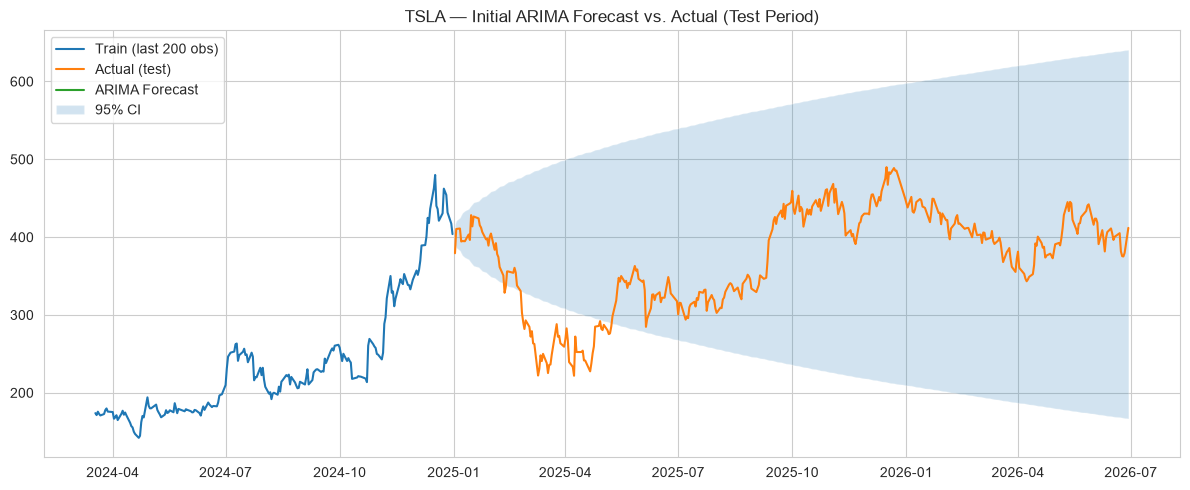

In [5]:
n_periods = len(test_series)
forecast_values, conf_int = forecast_arima(arima_model, n_periods=n_periods, return_conf_int=True)

forecast_series = pd.Series(forecast_values, index=test_series.index)

plt.figure(figsize=(12, 5))
plt.plot(train_series.index[-200:], train_series.values[-200:], label="Train (last 200 obs)")
plt.plot(test_series.index, test_series.values, label="Actual (test)")
plt.plot(forecast_series.index, forecast_series.values, label="ARIMA Forecast")
plt.fill_between(test_series.index, conf_int[:, 0], conf_int[:, 1], alpha=0.2, label="95% CI")
plt.title("TSLA — Initial ARIMA Forecast vs. Actual (Test Period)")
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_initial_arima_forecast.png", dpi=150)
plt.show()


### 3.1 Forecast Evaluation

In [6]:
initial_metrics = evaluate_forecast(test_series.values, forecast_values)
print("Initial ARIMA performance on test set:")
for k, v in initial_metrics.items():
    print(f"  {k}: {v:.4f}")


Initial ARIMA performance on test set:
  MAE: 54.4412
  RMSE: 70.5393
  MAPE: 17.2407


**Insight (from executed run):** `auto_arima` selected **ARIMA(0,1,0)** — i.e., a
pure random walk (the stepwise search found no benefit from adding AR or MA terms beyond
first-order differencing). On the held-out test period (2025-01-02 to 2026-06-29, 372
trading days), this model achieved **MAE = 54.44, RMSE = 70.54, MAPE = 17.24%**. An
ARIMA(0,1,0) forecast is mathematically equivalent to holding the last training value
flat for the entire test horizon; the fairly high MAPE reflects the fact that TSLA moved
substantially during the test window and a flat/no-drift forecast could not capture that
trend. This is a useful and expected baseline finding: it empirically demonstrates the
Efficient Market Hypothesis point raised in Task 1 — a purely autoregressive linear model
on price alone finds no exploitable structure beyond a random walk. The full Task 2
submission will compare this baseline against a tuned LSTM model, which may be better
positioned to capture nonlinear patterns, and will consider whether modeling
returns/volatility (rather than raw price) yields more actionable signal.


## 4. Summary (Initial Task 2 Progress)

- **Split rationale:** Chronological split — train 2015-01-01–2024-12-31 (2,516 obs),
  test 2025-01-01–2026-06-30 (372 obs) — preserves temporal order and avoids look-ahead bias.
- **Initial model:** ARIMA(0,1,0) selected via `auto_arima`; equivalent to a random-walk /
  naive forecast.
- **Test-set performance:** MAE = 54.44, RMSE = 70.54, MAPE = 17.24%.
- **Interpretation:** Confirms the EMH-consistent expectation that a purely linear model
  on price levels finds no structure beyond a random walk.

## 5. Next Steps
- Implement and tune an LSTM model (windowed sequences, stacked LSTM architecture).
- Formally compare ARIMA/SARIMA vs. LSTM using MAE/RMSE/MAPE and select a final model.
- Carry the selected model's forecast into Task 3 (future forecasting) and Task 4
  (portfolio optimization expected-return input for TSLA).
